## **Time Series Forecasting**
### **Reproduksi dari**: https://skforecast.org/0.15.1/user_guides/explainability.html

### **1. Prediksi Tentang Apa?**
Notebook ini menjelaskan cara **memahami dan menjelaskan** model peramalan deret waktu (time series forecasting).  
Kita akan memprediksi **konsumsi listrik per 30 menit** di Victoria, Australia, lalu menggunakan berbagai teknik untuk menjawab:

> *"Kenapa model memberikan prediksi ini? Faktor apa yang paling berpengaruh?"*

### Teknik yang digunakan:
| Teknik | Fungsi |
|--------|--------|
| **Feature Importance** | Fitur mana yang paling sering dipakai model? |
| **Permutation Importance** | Seberapa penting tiap fitur kalau diacak? |
| **SHAP Values** | Kontribusi tiap fitur per prediksi |
| **Partial Dependence Plot** | Hubungan rata-rata fitur vs prediksi |

### **2. Bentuk Data Training**
#### a. Dari Deret Waktu ke Tabel Biasa

Data aslinya hanya satu kolom angka yang berurutan:

```
Waktu                  Demand (MWh)
2012-01-01 00:00       4382.8
2012-01-01 00:30       4263.4
2012-01-01 01:00       4048.8
2012-01-01 01:30       3877.2
...
```

`skforecast` otomatis mengubah ini menjadi **tabel supervised learning** menggunakan konsep **lag**.

### Matriks Training yang Terbentuk

Dengan `lags=24`, setiap baris di matriks training terbentuk seperti ini:

$$
\mathbf{X} =
\begin{bmatrix}
\underbrace{y_{t-1}}_{\texttt{lag\_1}} & \underbrace{y_{t-2}}_{\texttt{lag\_2}} & \cdots & \underbrace{y_{t-24}}_{\texttt{lag\_24}}
\end{bmatrix},
\quad
\mathbf{y} = y_t
$$

Secara lengkap, matriks $\mathbf{X} \in \mathbb{R}^{n \times 24}$ dan target $\mathbf{y} \in \mathbb{R}^{n}$ adalah:

$$
\mathbf{X} = \begin{bmatrix}
y_{t_1-1} & y_{t_1-2} & \cdots & y_{t_1-24} \\
y_{t_2-1} & y_{t_2-2} & \cdots & y_{t_2-24} \\
\vdots    & \vdots    & \ddots & \vdots     \\
y_{t_n-1} & y_{t_n-2} & \cdots & y_{t_n-24}
\end{bmatrix},
\qquad
\mathbf{y} = \begin{bmatrix} y_{t_1} \\ y_{t_2} \\ \vdots \\ y_{t_n} \end{bmatrix}
$$

#### b.Ringkasan Input dan Output

| Komponen | Keterangan |
|---|---|
| **Input $X$** | `lag_1` s.d. `lag_24` — nilai historis demand 30 menit lalu hingga 12 jam lalu |
| **Output $y$** | Nilai demand pada waktu $t$ yang ingin diprediksi |
| **Ukuran X** | $\approx 34.000 \times 24$ (baris = sampel, kolom = fitur lag) |
| **Tipe masalah** | Supervised Regression |
---

### **3. Apa itu Lag?**
#### a. Definisi Sederhana

**Lag** adalah nilai dari masa lalu. Lag ke-$k$ berarti *"nilai $k$ langkah sebelum waktu sekarang"*.

$$\text{lag}_k = y_{t-k}, \quad k = 1, 2, 3, \ldots, 24$$

#### b. Analogi Mudah

Bayangkan kamu diminta menebak cuaca besok. Kamu pasti akan lihat:
- Cuaca hari ini → ini `lag_1`
- Cuaca kemarin → ini `lag_2`
- Cuaca seminggu lalu → ini `lag_7`

Begitu juga model kita. Untuk menebak konsumsi listrik pukul **14:00**, model melihat:

| Fitur | Nilai yang Dipakai | Penjelasan |
|---|---|---|
| `lag_1` | Nilai pukul 13:30 | 30 menit sebelumnya |
| `lag_2` | Nilai pukul 13:00 | 1 jam sebelumnya |
| `lag_3` | Nilai pukul 12:30 | 1.5 jam sebelumnya |
| `lag_24` | Nilai pukul 02:00 | 12 jam sebelumnya |

#### c. Ilustrasi Visual

```
Waktu:   ...  [11:00]  [11:30]  [12:00]  ...  [13:00]  [13:30]  ← [14:00]?
                 │        │        │              │        │            ↑
                lag_6    lag_5    lag_4          lag_2    lag_1     TARGET
```

#### d.Mengapa Lag Penting?

Karena dalam data listrik ada **autokorelasi** — konsumsi saat ini sangat dipengaruhi konsumsi sebelumnya. Secara matematis:

$$y_t = f\bigl(y_{t-1},\ y_{t-2},\ \ldots,\ y_{t-24}\bigr) + \varepsilon_t$$

Di mana $f(\cdot)$ adalah fungsi yang dipelajari LightGBM dan $\varepsilon_t$ adalah error residual.

**Pola yang ditangkap lag:**
- `lag_1` → tren sesaat (30 menit lalu masih tinggi → sekarang mungkin masih tinggi)
- `lag_24` sampai `lag_48` → pola harian (jam 14:00 kemarin seperti apa?)
- `lag_336` → pola mingguan (minggu lalu jam 14:00 seperti apa?)

### **4. Proses Analisis yang Dilakukan**
#### a. Alur Keseluruhan

```
[Data deret waktu vic_electricity]
          │
          ▼
[Transformasi → Matriks lag_1 ... lag_24]
          │
          ▼
[Training: LGBMRegressor via ForecasterRecursive]
          │
    ┌─────┼──────────────────────┐
    ▼     ▼                      ▼
 [6.1]  [6.2]                 [6.3]
Feature  Permutation         SHAP Values
Importance Importance      ┌───┼───┐
                         Summary Bar Force PDP
                          Plot  Plot Plot
```

#### b.Feature Importance (Bawaan LightGBM)

Cara paling sederhana. LightGBM menghitung seberapa sering tiap fitur dipakai untuk **membelah (split)** node di dalam pohon keputusan.

$$I_j = \sum_{t=1}^{T} \sum_{\text{node} \in t} \mathbf{1}[\text{split pada fitur } j] \times \Delta\text{impurity}$$

```python
# Ambil feature importance dari forecaster
feat_imp = forecaster.get_feature_importances()
print(feat_imp.head(10))
```

**Hasilnya biasanya:**
- `lag_1` = skor tertinggi (nilai 30 menit lalu paling sering dipakai)
- Semakin besar lag → semakin kecil skornya

>**Kelemahan:** Hanya menunjukkan frekuensi pemakaian, bukan seberapa besar dampaknya pada prediksi.


#### c. Permutation Importance

Ide dasarnya sederhana: **"Kalau fitur ini tidak penting, mengacak nilainya tidak akan memperburuk model."**

**Cara kerja:**
1. Hitung error model awal → $E_{\text{awal}}$
2. Acak secara acak nilai satu fitur (misalnya `lag_1`) → $\mathbf{X}^{\pi_j}$
3. Hitung error baru → $E_{\text{baru}}$
4. Selisih = seberapa penting fitur itu

$$PI_j = \frac{1}{K} \sum_{k=1}^{K} \Bigl[ L\bigl(\mathbf{y},\ \hat{f}(\mathbf{X}^{\pi_j^k})\bigr) - L\bigl(\mathbf{y},\ \hat{f}(\mathbf{X})\bigr) \Bigr]$$

Di mana $L$ = fungsi error (MSE), $K$ = jumlah pengulangan (default 10), $\pi_j^k$ = permutasi ke-$k$ pada fitur $j$.

```python
from sklearn.inspection import permutation_importance

result = permutation_importance(
    estimator    = forecaster.regressor,
    X            = X_train,
    y            = y_train,
    n_repeats    = 10,
    random_state = 123,
    n_jobs       = -1
)
```

>**Kelebihan:** Model-agnostic (bisa dipakai untuk model apapun), hasilnya lebih bermakna dari sekedar frekuensi split.


#### d. SHAP Values(Teknik Paling Canggih)

**SHAP** = SHapley Additive exPlanations. Berasal dari **teori permainan (game theory)** — konsep Shapley value yang menghitung kontribusi adil tiap "pemain" dalam sebuah koalisi.

**Ide utamanya:** Setiap prediksi $\hat{y}_i$ bisa dipecah-pecah menjadi kontribusi masing-masing fitur:

$$\hat{y}_i = \underbrace{\phi_0}_{\text{baseline}} + \underbrace{\phi_{i,1}}_{\text{kontrib. lag\_1}} + \underbrace{\phi_{i,2}}_{\text{kontrib. lag\_2}} + \cdots + \underbrace{\phi_{i,24}}_{\text{kontrib. lag\_24}}$$

Di mana:
- $\phi_0$ = baseline (rata-rata prediksi model pada semua data training)
- $\phi_{i,j}$ = kontribusi fitur $j$ pada prediksi ke-$i$ (bisa positif atau negatif)

##### Rumus Shapley Value

$$\phi_j = \sum_{S \subseteq \mathcal{F} \setminus \{j\}} \frac{|S|!\,(|\mathcal{F}|-|S|-1)!}{|\mathcal{F}|!} \Bigl[ v(S \cup \{j\}) - v(S) \Bigr]$$

Di mana $\mathcal{F}$ = himpunan semua fitur dan $v(S)$ = prediksi model menggunakan subset fitur $S$.

Intinya: **berapa rata-rata tambahan kontribusi fitur $j$ jika dimasukkan ke dalam semua kemungkinan kombinasi fitur lain?**

```python
import shap

shap.initjs()
explainer   = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

# shap_values.shape = (34000+, 24)
# → satu nilai SHAP per fitur per observasi
```

##### Tiga Jenis Visualisasi SHAP

**A. Summary Plot (Beeswarm)** — gambaran global semua observasi

```python
shap.summary_plot(shap_values, X_train, max_display=24)
```

Cara membacanya:
- Sumbu X = nilai SHAP → positif berarti mendorong prediksi **naik**
- Warna titik = nilai fitur asli → merah = tinggi, biru = rendah
- Setiap titik = satu observasi

**B. Bar Plot** — rata-rata kontribusi absolut

$$\bar{|\phi_j|} = \frac{1}{n} \sum_{i=1}^{n} |\phi_{i,j}|$$

```python
shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=24)
```

**C. Force Plot** — penjelasan untuk SATU prediksi spesifik

```python
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :]
)
```

Cara membacanya:
- Bagian **merah** = fitur yang mendorong prediksi **ke atas** dari baseline
- Bagian **biru** = fitur yang mendorong prediksi **ke bawah** dari baseline
- Panjang bagian = seberapa besar kontribusinya

**D. Dependence Plot** — hubungan nilai fitur vs kontribusinya

```python
shap.dependence_plot('lag_1', shap_values, X_train)
```

>**Kelebihan SHAP:** Bisa menjawab *per prediksi*, bukan hanya rata-rata global. Misalnya: "Prediksi jam 14:00 hari Senin ini tinggi karena `lag_1`-nya sedang 5000 MWh, yang berkontribusi +800 MWh dari baseline."

#### e. Partial Dependence Plot (PDP)

PDP menjawab pertanyaan: **"Kalau saya ubah-ubah nilai satu fitur, rata-rata prediksinya berubah seperti apa?"**

$$\hat{f}_j(x_j) = \mathbb{E}_{\mathbf{X}_{\setminus j}}\!\left[\hat{f}(x_j,\, \mathbf{X}_{\setminus j})\right] \approx \frac{1}{n} \sum_{i=1}^{n} \hat{f}\!\left(x_j,\, \mathbf{x}_i^{\setminus j}\right)$$

Di mana $\mathbf{X}_{\setminus j}$ = semua fitur kecuali fitur $j$ yang sedang dianalisis.

**Caranya:** Untuk setiap nilai $x_j$ yang ingin diperiksa, model dijalankan pada semua data training dengan fitur $j$ diganti nilainya, lalu hasilnya dirata-rata.

```python
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    estimator     = forecaster.regressor,
    X             = X_train,
    features      = ['lag_1', 'lag_2', 'lag_24'],
    kind          = 'average'
)
plt.show()
```

>**Kelebihan PDP:** Mudah diinterpretasi — garisnya naik berarti hubungan positif, turun berarti negatif.  
>**Kelemahan:** Mengasumsikan fitur-fitur saling independen (tidak selalu benar di data nyata).

##### 📊 Perbandingan Keempat Teknik

| Teknik | Jenis | Global/Lokal | Yang Dijawab |
|---|---|---|---|
| **Feature Importance** | Model-specific | Global | Fitur mana paling sering dipakai pohon? |
| **Permutation Importance** | Model-agnostic | Global | Fitur mana yang paling merusak model jika diacak? |
| **SHAP Values** | Model-agnostic | Global **dan** Lokal | Berapa kontribusi tiap fitur per prediksi? |
| **PDP** | Model-agnostic | Global | Bagaimana hubungan rata-rata satu fitur dengan output? |

**Global** = berlaku untuk keseluruhan model/dataset  
**Lokal** = berlaku untuk satu prediksi spesifik


##### 💡 Temuan Utama dari Kasus Ini

Setelah menjalankan semua analisis, ditemukan:

1. **`lag_1` paling berpengaruh** — konsumsi 30 menit lalu adalah prediktor terkuat untuk saat ini
2. **`lag_2` dan `lag_3` juga signifikan** — tren jangka pendek penting
3. **`lag_24` dan `lag_48`** — pola harian terulang secara konsisten
4. **Hubungan monoton positif** — semakin tinggi nilai lag → semakin tinggi prediksi (terlihat di PDP)
5. **Model LightGBM bisa dijelaskan** — bukan sekadar "kotak hitam"

### **IMPLEMENTASI KODE DAN EKSPERIMEN (NOTEBOOK)**

#### 📦 Step 1 — Install Library

Jalankan cell ini pertama kali di Google Colab. Kalau di local Jupyter, pastikan sudah install semua library-nya.

In [1]:
# Install semua library yang dibutuhkan
# Jalankan cell ini hanya sekali, lalu restart runtime jika diminta
!pip install skforecast lightgbm shap --quiet
print("✅ Semua library berhasil diinstall!")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


✅ Semua library berhasil diinstall!


#### 📚 Step 2 — Import Library

In [2]:
# ============================================================================
# Import semua library dan modul spesifik yang digunakan
# ============================================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor

# Library utama untuk peramalan deret waktu
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Mengatur tampilan grafik agar rapi
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Semua library berhasil di-import dan siap digunakan!")

✅ Semua library berhasil di-import dan siap digunakan!


#### 📊 Step 3 — Load dan Eksplorasi Data

Dataset yang dipakai adalah `vic_electricity` — data konsumsi listrik per 30 menit di **Victoria, Australia**.

```
Kolom penting:
  Demand  = konsumsi listrik dalam MWh  ← ini yang kita prediksi
  Date    = tanggal dan jam pengukuran
```

In [3]:
# Load dataset vic_electricity
data_raw = fetch_dataset('vic_electricity', raw=True)
print("📋 Bentuk data asli:", data_raw.shape)
print()
data_raw.head()

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 5)
📋 Bentuk data asli: (52608, 5)



,Time,Demand,Temperature,Date,Holiday
0,2011-12-31T13:00:00Z,4382.825174,21.40,2012-01-01,True
1,2011-12-31T13:30:00Z,4263.365526,21.05,2012-01-01,True
2,2011-12-31T14:00:00Z,4048.966046,20.70,2012-01-01,True
3,2011-12-31T14:30:00Z,3877.563330,20.55,2012-01-01,True
4,2011-12-31T15:00:00Z,4036.229746,20.40,2012-01-01,True


In [4]:
# Preprocessing: set index waktu, ambil kolom Demand saja
data = data_raw.copy()
data['Time'] = pd.to_datetime(data['Time'])
data = data.set_index('Time')
data = data.asfreq('30min')  # frekuensi 30 menit
data = data['Demand']        # ambil kolom target saja

print("✅ Data siap!")
print(f"   Jumlah data : {len(data):,} baris")
print(f"   Periode     : {data.index.min()} → {data.index.max()}")
print(f"   Demand min  : {data.min():.1f} MWh")
print(f"   Demand max  : {data.max():.1f} MWh")
print(f"   Demand rata : {data.mean():.1f} MWh")
print()
data.head(10)

✅ Data siap!
   Jumlah data : 52,608 baris
   Periode     : 2011-12-31 13:00:00+00:00 → 2014-12-31 12:30:00+00:00
   Demand min  : 2857.9 MWh
   Demand max  : 9345.0 MWh
   Demand rata : 4665.4 MWh



Time
2011-12-31 13:00:00+00:00    4382.825174
2011-12-31 13:30:00+00:00    4263.365526
2011-12-31 14:00:00+00:00    4048.966046
2011-12-31 14:30:00+00:00    3877.563330
2011-12-31 15:00:00+00:00    4036.229746
2011-12-31 15:30:00+00:00    3865.597244
2011-12-31 16:00:00+00:00    3694.097664
2011-12-31 16:30:00+00:00    3561.623686
2011-12-31 17:00:00+00:00    3433.035352
2011-12-31 17:30:00+00:00    3359.468000
Freq: 30min, Name: Demand, dtype: float64

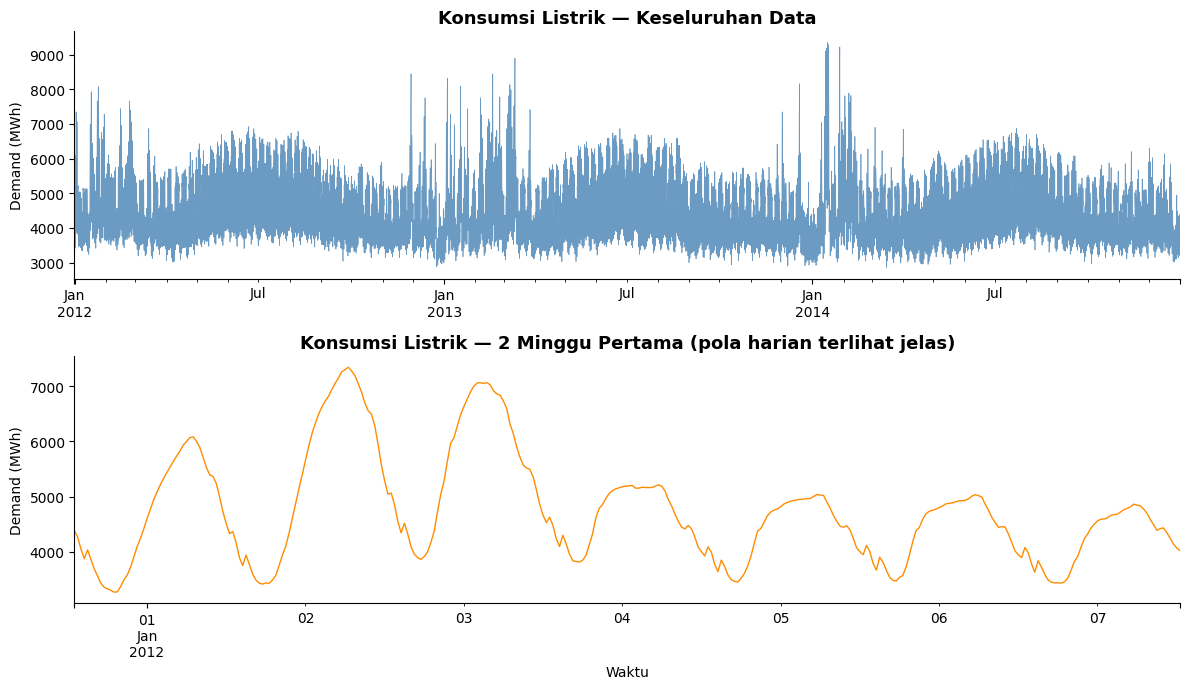

💡 Perhatikan pola naik-turun harian — ini yang akan ditangkap oleh lag!


In [5]:
# Visualisasi data — lihat 1 bulan pertama
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Plot keseluruhan
data.plot(ax=axes[0], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Konsumsi Listrik — Keseluruhan Data', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MWh)')
axes[0].set_xlabel('')

# Plot 2 minggu pertama (lebih detail)
data.iloc[:24*2*7].plot(ax=axes[1], color='darkorange', linewidth=1)
axes[1].set_title('Konsumsi Listrik — 2 Minggu Pertama (pola harian terlihat jelas)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MWh)')
axes[1].set_xlabel('Waktu')

plt.tight_layout()
plt.show()

print("💡 Perhatikan pola naik-turun harian — ini yang akan ditangkap oleh lag!")

#### 🕐 Step 4 — Memahami Konsep LAG

**Lag** adalah cara kita "memberi tahu" model tentang masa lalu.

Dengan `lags=24`, kita memberikan model:
- `lag_1` = nilai 30 menit yang lalu
- `lag_2` = nilai 1 jam yang lalu  
- `lag_24` = nilai 12 jam yang lalu

Secara matematis:
$$\hat{y}_t = f(y_{t-1},\ y_{t-2},\ \ldots,\ y_{t-24})$$

Model belajar pola: *"kalau 30 menit lalu konsumsi tinggi, kemungkinan sekarang juga masih tinggi"*

In [6]:
# Ilustrasi manual bagaimana lag dibentuk
contoh = data.iloc[:6].copy()
df_lag = pd.DataFrame({
    'Waktu'   : contoh.index,
    'lag_3 (y_{t-3})': contoh.values,
    'lag_2 (y_{t-2})': contoh.shift(-1).values,
    'lag_1 (y_{t-1})': contoh.shift(-2).values,
    'TARGET y_t'     : contoh.shift(-3).values,
}).dropna()

print("📋 Contoh matriks training dengan lags=3:")
print()
print(df_lag.to_string(index=False))
print()
print("💡 Setiap baris = 1 sampel training.")
print("   Kolom lag_* = INPUT model")
print("   Kolom TARGET = yang harus diprediksi model")

📋 Contoh matriks training dengan lags=3:

                    Waktu  lag_3 (y_{t-3})  lag_2 (y_{t-2})  lag_1 (y_{t-1})  TARGET y_t
2011-12-31 13:00:00+00:00      4382.825174      4263.365526      4048.966046 3877.563330
2011-12-31 13:30:00+00:00      4263.365526      4048.966046      3877.563330 4036.229746
2011-12-31 14:00:00+00:00      4048.966046      3877.563330      4036.229746 3865.597244

💡 Setiap baris = 1 sampel training.
   Kolom lag_* = INPUT model
   Kolom TARGET = yang harus diprediksi model


#### 🤖 Step 5 — Membuat dan Melatih Forecaster

Kita pakai `ForecasterRecursive` dengan:
- **Regressor**: `LGBMRegressor` (LightGBM — model berbasis pohon, cepat dan akurat)
- **Lags**: 24 (gunakan 24 langkah = 12 jam ke belakang)

In [7]:
# Paksa install skforecast versi 0.15.1 agar semua parameter cocok
!pip install skforecast==0.15.1 lightgbm shap --quiet
print("✅ Library skforecast 0.15.1 berhasil diinstall!")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


✅ Library skforecast 0.15.1 berhasil diinstall!


In [8]:
# Membuat Forecaster
forecaster = ForecasterRecursive(
    regressor = LGBMRegressor(
        n_estimators  = 500,
        learning_rate = 0.05,
        max_depth     = 6,
        random_state  = 15926,
        verbose       = -1
    ),
    lags = 24
)

print("✅ Forecaster berhasil dibuat!")
print()
print(forecaster)

✅ Forecaster berhasil dibuat!

ForecasterRecursive 
Regressor: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: None 
Window size: 24 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: None 
Training index type: None 
Training index frequency: None 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 500, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 15926, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample':
    1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 07:59:15 
Last fit date: None 
Sk

In [9]:
# Latih (fit) model dengan seluruh data
print("⏳ Melatih model... (mungkin 10-30 detik)")
forecaster.fit(y=data)

print("✅ Model selesai dilatih!")
print(f"   Jumlah lag yang digunakan : {forecaster.lags}")

⏳ Melatih model... (mungkin 10-30 detik)


✅ Model selesai dilatih!
   Jumlah lag yang digunakan : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


In [10]:
# Ambil matriks training
X_train, y_train = forecaster.create_train_X_y(y=data)

print("📋 Matriks Training:")
print(f"   Shape X_train : {X_train.shape}  (baris=sampel, kolom=lag)")
print(f"   Shape y_train : {y_train.shape}")
print()
print("5 baris pertama X_train:")
X_train.head()

📋 Matriks Training:
   Shape X_train : (52584, 24)  (baris=sampel, kolom=lag)
   Shape y_train : (52584,)

5 baris pertama X_train:


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
Time,,,,,,,,,,,,,,,,,,,,,
2012-01-01 01:00:00+00:00,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,3580.091164,3494.418154,3370.424090,...,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330,4048.966046,4263.365526,4382.825174
2012-01-01 01:30:00+00:00,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,3580.091164,3494.418154,...,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330,4048.966046,4263.365526
2012-01-01 02:00:00+00:00,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,3580.091164,...,3304.641186,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330,4048.966046
2012-01-01 02:30:00+00:00,5211.915476,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,...,3272.106404,3304.641186,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330
2012-01-01 03:00:00+00:00,5328.317180,5211.915476,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,...,3275.998060,3272.106404,3304.641186,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746


#### 🔬 Step 6 — EXPLAINABILITY

Sekarang bagian utamanya! Kita akan menggunakan 4 teknik untuk memahami model.

##### 6.1 — Feature Importance (Bawaan LightGBM)

Cara paling simpel: tanya langsung ke modelnya.  
LightGBM menghitung seberapa sering tiap fitur dipakai untuk **membelah (split)** node di pohon keputusan.

$$I_j = \sum_{\text{semua pohon}} \sum_{\text{node yang split pada } j} \Delta\text{impurity}$$

In [11]:
# ============================================================================
# Feature Importance dari ForecasterRecursive
# ============================================================================
feat_imp = forecaster.get_feature_importances()
print("Top 10 fitur terpenting:")
print(feat_imp.head(10).to_string(index=False))

Top 10 fitur terpenting:
feature  importance
  lag_1        2536
  lag_2        1468
  lag_4        1039
  lag_3         960
 lag_24         763
  lag_5         716
 lag_17         569
 lag_15         563
 lag_13         459
 lag_16         431


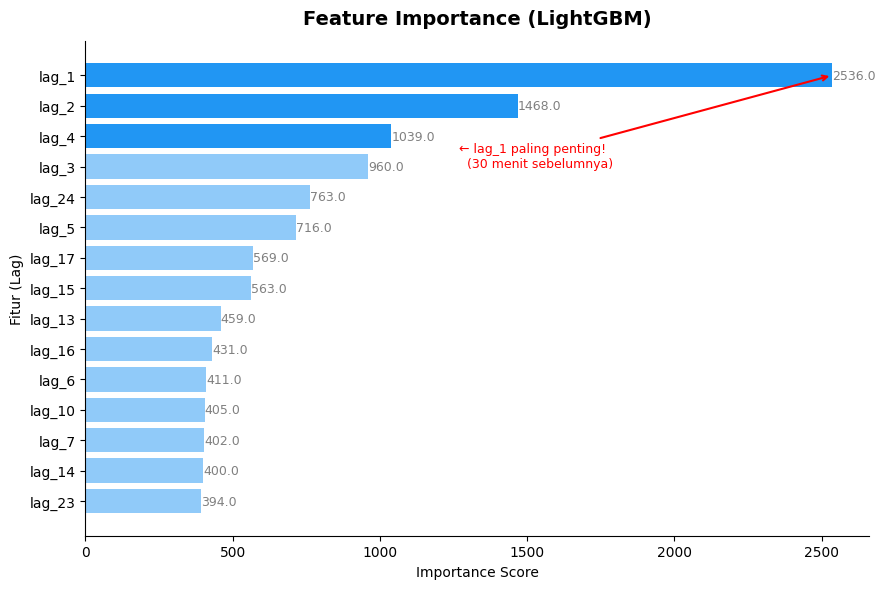

💡 lag_1 (30 menit lalu) = paling berpengaruh
   Makin besar lag → makin kecil pengaruhnya (wajar!)


In [12]:
# Visualisasi Feature Importance
fig, ax = plt.subplots(figsize=(9, 6))

# Sort dan ambil top 15
top = feat_imp.sort_values('importance', ascending=True).tail(15)

colors = ['#2196F3' if i >= len(top)-3 else '#90CAF9' for i in range(len(top))]
bars = ax.barh(top['feature'], top['importance'], color=colors, edgecolor='none')

ax.set_title('Feature Importance (LightGBM)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Fitur (Lag)')
ax.tick_params(axis='y', labelsize=10)

# Tambah label nilai di kanan bar
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}', va='center', ha='left', fontsize=9, color='gray')

ax.annotate('← lag_1 paling penting!\n  (30 menit sebelumnya)',
            xy=(top['importance'].iloc[-1], 14),
            xytext=(top['importance'].max()*0.5, 11),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=9, color='red')

plt.tight_layout()
plt.show()

print("💡 lag_1 (30 menit lalu) = paling berpengaruh")
print("   Makin besar lag → makin kecil pengaruhnya (wajar!)")

##### 6.2 — Permutation Importance

Ide dasarnya: **"Kalau fitur ini tidak ada gunanya, mengacak nilainya tidak akan mempengaruhi model."**

Caranya:
1. Hitung error awal model
2. Acak satu fitur (misalnya `lag_1`)
3. Hitung error baru
4. Selisihnya = seberapa penting fitur itu

$$PI_j = \frac{1}{K} \sum_{k=1}^{K} \left[ \text{Error}(\mathbf{X}^{\text{diacak}_j}) - \text{Error}(\mathbf{X}) \right]$$

In [13]:
# Permutation Importance
print("⏳ Menghitung permutation importance... (mungkin 1-2 menit)")

result = permutation_importance(
    estimator  = forecaster.regressor,
    X          = X_train,
    y          = y_train,
    n_repeats  = 10,     # diulangi 10 kali untuk stabilitas
    random_state = 123,
    n_jobs     = -1,     # pakai semua CPU
    scoring    = 'neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature'        : X_train.columns,
    'importance_mean': result.importances_mean,
    'importance_std' : result.importances_std
}).sort_values('importance_mean', ascending=False)

print("✅ Selesai! Top 10 fitur:")
print(perm_df.head(10).to_string(index=False))

⏳ Menghitung permutation importance... (mungkin 1-2 menit)


KeyboardInterrupt: 

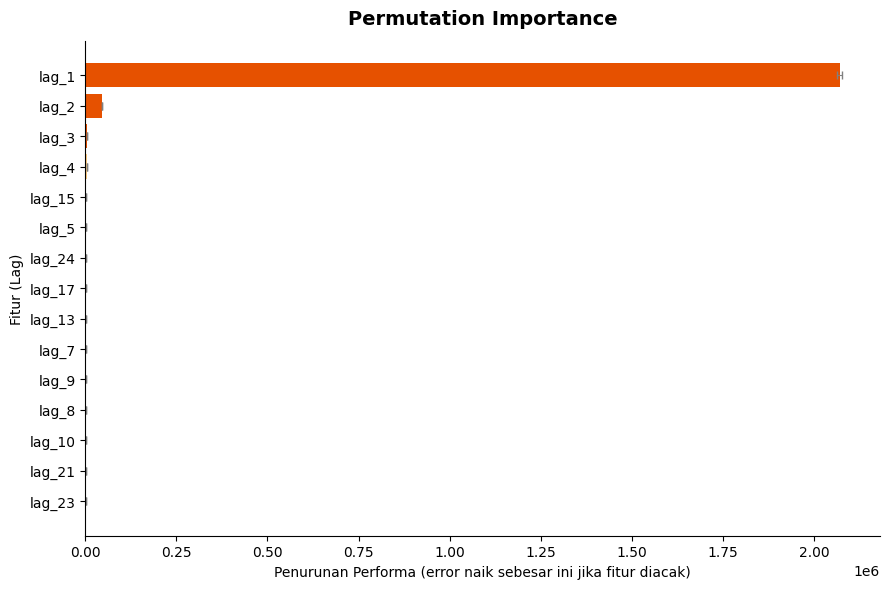

💡 Error bar menunjukkan variabilitas antar 10 kali pengulangan
   Semakin besar nilai = semakin penting fitur tersebut


In [13]:
# Visualisasi Permutation Importance
fig, ax = plt.subplots(figsize=(9, 6))

top_perm = perm_df.sort_values('importance_mean', ascending=True).tail(15)
colors_p = ['#E65100' if i >= len(top_perm)-3 else '#FFCC80' for i in range(len(top_perm))]

ax.barh(
    top_perm['feature'],
    top_perm['importance_mean'],
    xerr=top_perm['importance_std'],
    color=colors_p,
    capsize=3,
    edgecolor='none',
    error_kw={'ecolor': 'gray', 'elinewidth': 0.8}
)

ax.set_title('Permutation Importance', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Penurunan Performa (error naik sebesar ini jika fitur diacak)')
ax.set_ylabel('Fitur (Lag)')
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

print("💡 Error bar menunjukkan variabilitas antar 10 kali pengulangan")
print("   Semakin besar nilai = semakin penting fitur tersebut")

##### 6.3 — SHAP Values (SHapley Additive exPlanations)

Teknik paling canggih dan paling informatif. Setiap prediksi dipecah menjadi kontribusi masing-masing fitur:

$$\hat{y}_i = \underbrace{\phi_0}_{\text{baseline}} + \underbrace{\phi_{i,1}}_{\text{kontrib. lag\_1}} + \underbrace{\phi_{i,2}}_{\text{kontrib. lag\_2}} + \ldots + \underbrace{\phi_{i,24}}_{\text{kontrib. lag\_24}}$$

Berbeda dengan feature importance yang global, SHAP bisa menjawab:
> *"Untuk prediksi pukul 14:00 hari Senin INI, kontribusi lag_1 adalah +200 MWh"*

In [14]:
# Hitung SHAP Values menggunakan TreeExplainer
# (TreeExplainer khusus untuk model berbasis pohon seperti LightGBM)
print("⏳ Menghitung SHAP values... (mungkin 1-2 menit)")

shap.initjs()  # inisialisasi JavaScript untuk visualisasi interaktif

explainer   = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

print(f"✅ SHAP values berhasil dihitung!")
print(f"   Shape: {shap_values.shape}")
print(f"   Artinya: {shap_values.shape[0]:,} observasi × {shap_values.shape[1]} fitur")
print(f"   Baseline (rata-rata prediksi): {explainer.expected_value:.2f} MWh")

⏳ Menghitung SHAP values... (mungkin 1-2 menit)


✅ SHAP values berhasil dihitung!
   Shape: (52584, 24)
   Artinya: 52,584 observasi × 24 fitur
   Baseline (rata-rata prediksi): 4665.81 MWh


📊 SHAP Summary Plot — kontribusi semua fitur:



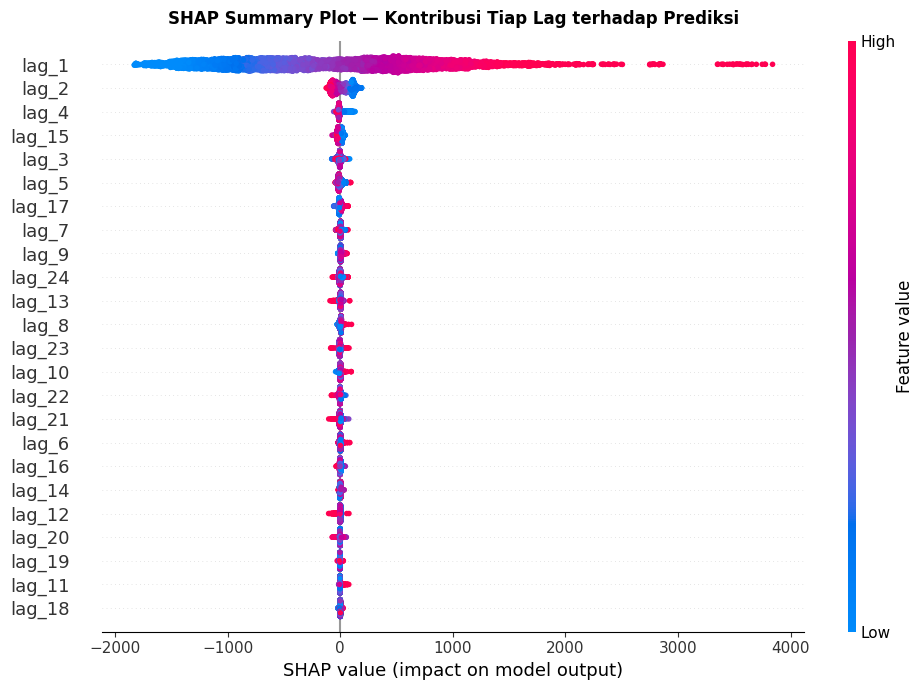

💡 Cara baca:
   Titik merah di kanan  = nilai lag tinggi → mendorong prediksi NAIK
   Titik biru di kiri    = nilai lag rendah → mendorong prediksi TURUN
   Fitur di atas lebih berpengaruh daripada yang di bawah


In [15]:
# SHAP Summary Plot (Beeswarm) — gambaran besar
# Cara baca:
#   - Sumbu X = nilai SHAP (positif = mendorong prediksi NAIK)
#   - Warna titik = nilai fitur asli (merah=tinggi, biru=rendah)
#   - Tiap titik = satu observasi/prediksi
# ============================================================================
print("📊 SHAP Summary Plot — kontribusi semua fitur:")
print()

# Gunakan subset agar lebih cepat (5000 sampel acak)
idx = np.random.choice(len(X_train), 5000, replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values[idx],
    X_train.iloc[idx],
    max_display=24,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary Plot — Kontribusi Tiap Lag terhadap Prediksi',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("💡 Cara baca:")
print("   Titik merah di kanan  = nilai lag tinggi → mendorong prediksi NAIK")
print("   Titik biru di kiri    = nilai lag rendah → mendorong prediksi TURUN")
print("   Fitur di atas lebih berpengaruh daripada yang di bawah")

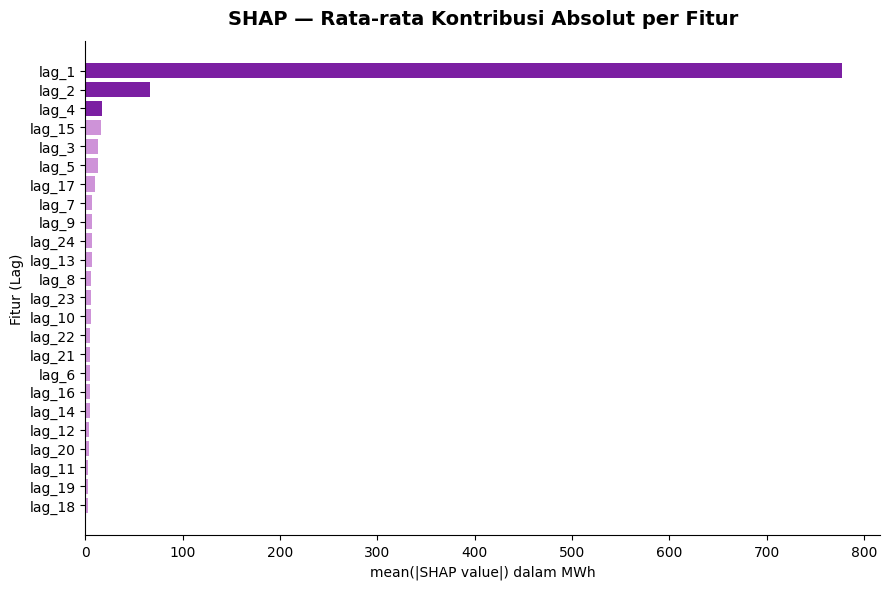

💡 Nilai ini berarti 'rata-rata, fitur ini mempengaruhi prediksi sebesar X MWh'


In [16]:
# SHAP Bar Plot — rata-rata kontribusi absolut
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'mean_shap' : mean_shap
}).sort_values('mean_shap', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_s = ['#7B1FA2' if i >= len(shap_df)-3 else '#CE93D8' for i in range(len(shap_df))]
ax.barh(shap_df['feature'], shap_df['mean_shap'], color=colors_s, edgecolor='none')
ax.set_title('SHAP — Rata-rata Kontribusi Absolut per Fitur', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('mean(|SHAP value|) dalam MWh')
ax.set_ylabel('Fitur (Lag)')
plt.tight_layout()
plt.show()

print("💡 Nilai ini berarti 'rata-rata, fitur ini mempengaruhi prediksi sebesar X MWh'")

🔍 Penjelasan untuk prediksi ke-100:
   Waktu      : 2012-01-03 03:00:00+00:00
   Nilai aktual: 7052.8 MWh
   Baseline    : 4665.8 MWh

   Top 5 kontributor:
   lag_1    =   7065.1 MWh  →  kontribusi +2468.4 MWh (↑ naik)
   lag_2    =   7057.8 MWh  →  kontribusi -89.7 MWh (↓ turun)
   lag_4    =   6896.6 MWh  →  kontribusi -33.9 MWh (↓ turun)
   lag_15   =   4369.9 MWh  →  kontribusi +25.9 MWh (↑ naik)
   lag_14   =   4717.3 MWh  →  kontribusi +25.1 MWh (↑ naik)

📊 Force Plot (tampilkan dengan shap.initjs() di Colab):


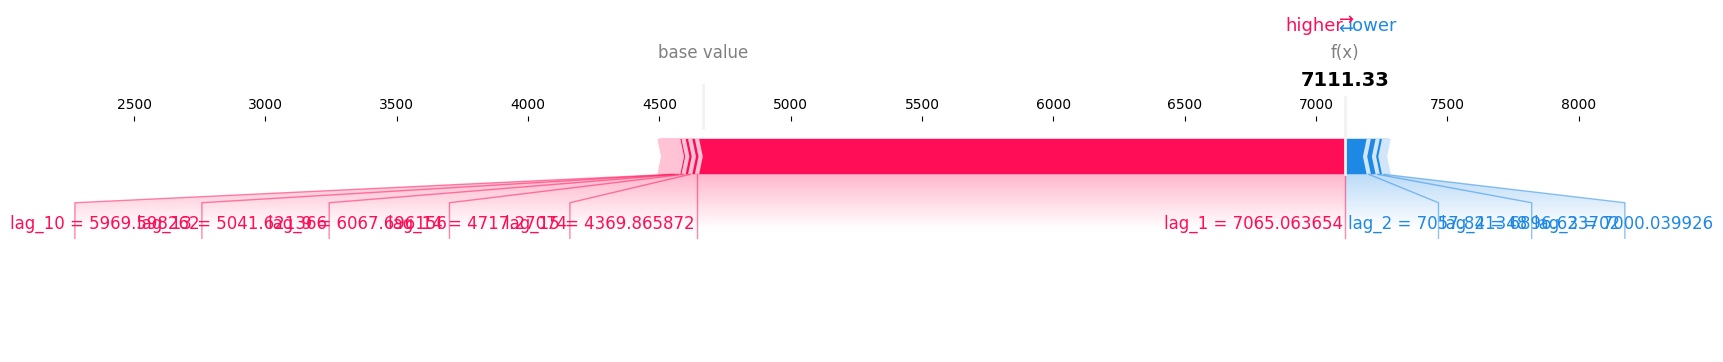

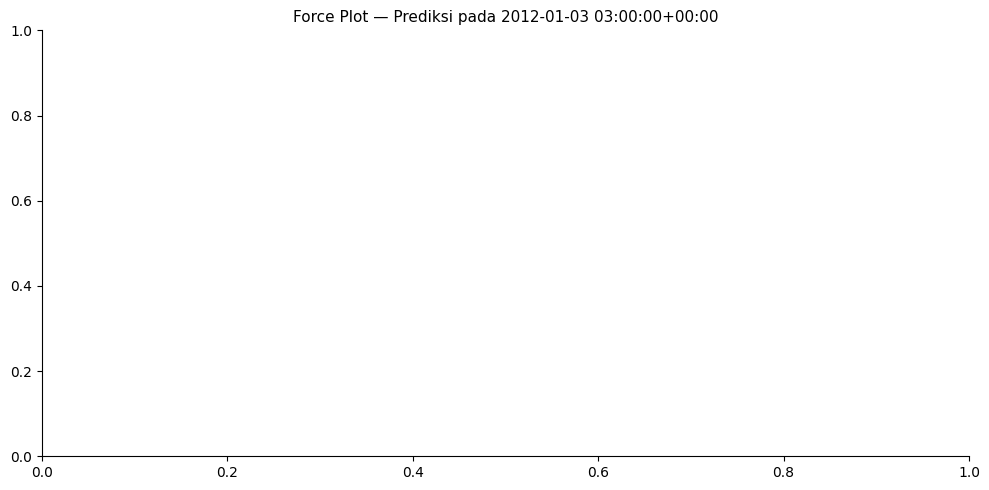

In [17]:
# SHAP Force Plot — penjelasan untuk SATU prediksi spesifik
idx_contoh = 100

print(f"🔍 Penjelasan untuk prediksi ke-{idx_contoh}:")
print(f"   Waktu      : {X_train.index[idx_contoh]}")
print(f"   Nilai aktual: {y_train.iloc[idx_contoh]:.1f} MWh")
print(f"   Baseline    : {explainer.expected_value:.1f} MWh")
print()

# Tampilkan 5 kontributor terbesar
contribs = pd.DataFrame({
    'fitur' : X_train.columns,
    'nilai_fitur': X_train.iloc[idx_contoh].values,
    'shap_value' : shap_values[idx_contoh]
}).sort_values('shap_value', key=abs, ascending=False)

print("   Top 5 kontributor:")
for _, row in contribs.head(5).iterrows():
    tanda = '+' if row['shap_value'] > 0 else ''
    arah  = '↑ naik' if row['shap_value'] > 0 else '↓ turun'
    print(f"   {row['fitur']:8s} = {row['nilai_fitur']:8.1f} MWh  →  kontribusi {tanda}{row['shap_value']:.1f} MWh ({arah})")

print()
print("📊 Force Plot (tampilkan dengan shap.initjs() di Colab):")

# Force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_contoh, :],
    X_train.iloc[idx_contoh, :],
    matplotlib=True
)
plt.title(f'Force Plot — Prediksi pada {X_train.index[idx_contoh]}', fontsize=11)
plt.tight_layout()
plt.show()

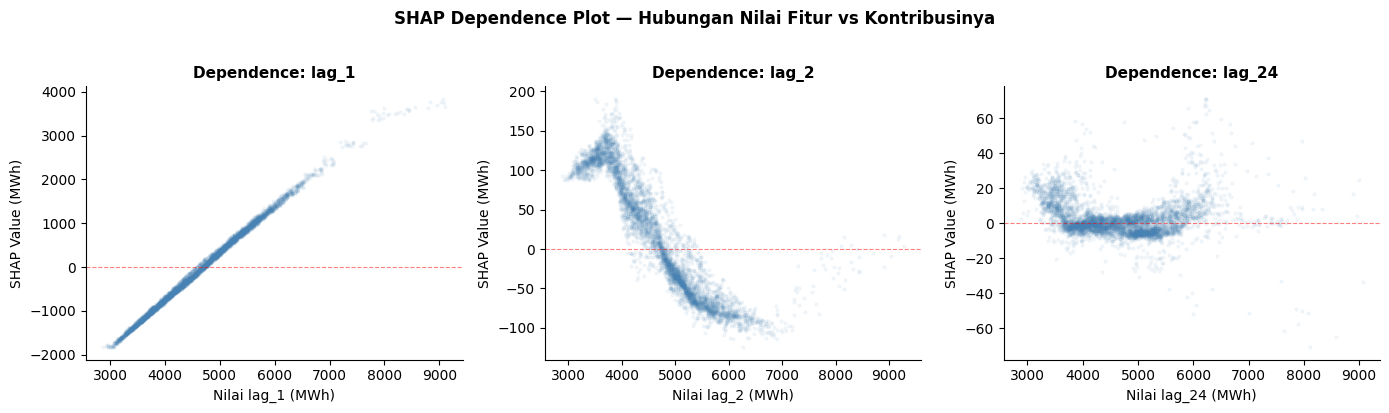

💡 Hubungan positif terlihat: semakin tinggi nilai lag → SHAP makin positif (prediksi naik)


In [18]:
# SHAP Dependence Plot — hubungan nilai fitur vs SHAP value-nya
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat in zip(axes, ['lag_1', 'lag_2', 'lag_24']):
    feat_idx = list(X_train.columns).index(feat)
    ax.scatter(
        X_train.iloc[idx, feat_idx],
        shap_values[idx, feat_idx],
        alpha=0.05, s=5, color='steelblue'
    )
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel(f'Nilai {feat} (MWh)', fontsize=10)
    ax.set_ylabel('SHAP Value (MWh)', fontsize=10)
    ax.set_title(f'Dependence: {feat}', fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plot — Hubungan Nilai Fitur vs Kontribusinya',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Hubungan positif terlihat: semakin tinggi nilai lag → SHAP makin positif (prediksi naik)")

##### 6.4 — Partial Dependence Plot (PDP)

PDP menunjukkan **hubungan rata-rata** antara satu fitur dan output prediksi, sambil menganggap fitur lain konstan.

$$\hat{f}_j(x_j) = \mathbb{E}_{\mathbf{X}_{\setminus j}}\left[\hat{f}(x_j, \mathbf{X}_{\setminus j})\right] \approx \frac{1}{n} \sum_{i=1}^{n} \hat{f}(x_j, \mathbf{x}_i^{\setminus j})$$

Intinya: *"Kalau saya ubah-ubah lag_1, rata-rata prediksinya seperti apa?"*

⏳ Menghitung PDP... (mungkin 30-60 detik)


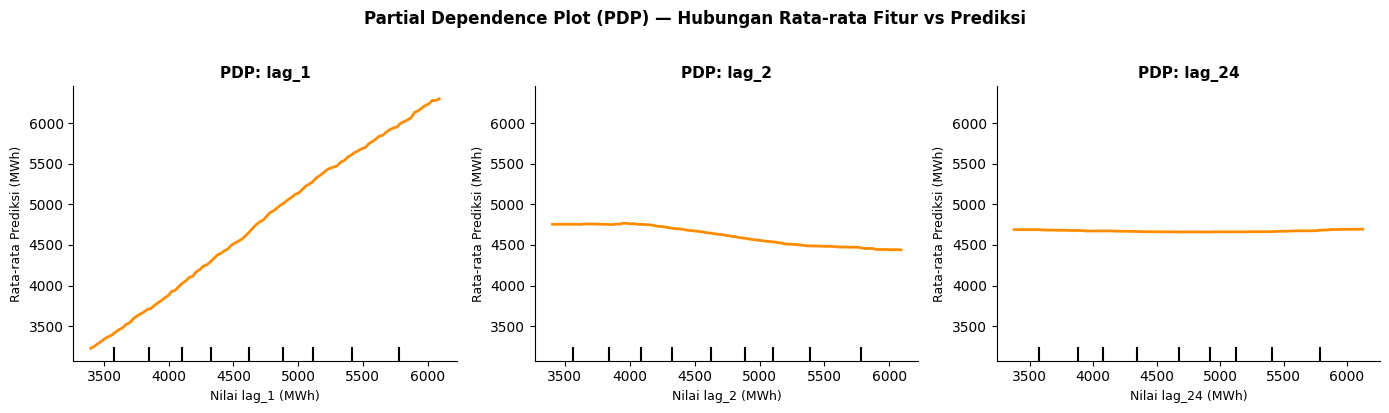

✅ Selesai!
💡 Slope naik = hubungan positif: nilai lag tinggi → prediksi tinggi


In [19]:
# Partial Dependence Plot
print("⏳ Menghitung PDP.. (mungkin 30-60 detik)")

features_pdp = ['lag_1', 'lag_2', 'lag_24']
feat_indices  = [list(X_train.columns).index(f) for f in features_pdp]

# Gunakan subset agar lebih cepat
X_sub = X_train.iloc[np.random.choice(len(X_train), 2000, replace=False)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

display = PartialDependenceDisplay.from_estimator(
    estimator  = forecaster.regressor,
    X          = X_sub,
    features   = feat_indices,
    feature_names = list(X_train.columns),
    kind       = 'average',
    ax         = axes,
    line_kw    = {'color': 'darkorange', 'linewidth': 2}
)

for ax, feat in zip(axes, features_pdp):
    ax.set_title(f'PDP: {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Nilai {feat} (MWh)', fontsize=9)
    ax.set_ylabel('Rata-rata Prediksi (MWh)', fontsize=9)

plt.suptitle('Partial Dependence Plot (PDP) — Hubungan Rata-rata Fitur vs Prediksi',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✅ Selesai!")
print("💡 Slope naik = hubungan positif: nilai lag tinggi → prediksi tinggi")

### 💡 Kesimpulan

- Nilai konsumsi 30 menit yang lalu (`lag_1`) = **paling berpengaruh**
- Pola harian (lag 24-48) juga signifikan
- Model **tidak sekadar blackbox** — bisa dijelaskan dengan baik
- SHAP adalah teknik paling informatif: bisa lihat pengaruh per prediksi

---

*Reproduksi dari [skforecast.org/0.15.1/user_guides/explainability](https://skforecast.org/0.15.1/user_guides/explainability.html)*